- 这是复现Jamming最简单的2D 模型

## 1. Press-Phi Curve for a 2D granular system

In [1]:
import os
print("当前工作目录:", os.getcwd())

当前工作目录: c:\Users\13557\Desktop\LammpsProject\shentongtong\Jamming\compress_rate


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 1、文件路径
file_path_slow_rate = "compress_rate_0.0001/press_phi_compress_rate_0.0001.txt"
file_path_rate_fast_rate  = "compress_rate_0.001/press_phi_compress_rate_0.001.txt"


# 2、读取函数
def load_press_phi(file_path):
    df = pd.read_csv(file_path, sep=r"\s+")

    phi = df["phi"].values
    press = df["press"].values
    # 保证按 phi 从小到大排序
    sort_idx = np.argsort(phi)
    phi = phi[sort_idx]
    press = press[sort_idx]
    
    return phi, press


# 3、读取两组数据
phi_slow, press_slow = load_press_phi(file_path_slow_rate)
phi_fast, press_fast = load_press_phi(file_path_rate_fast_rate)

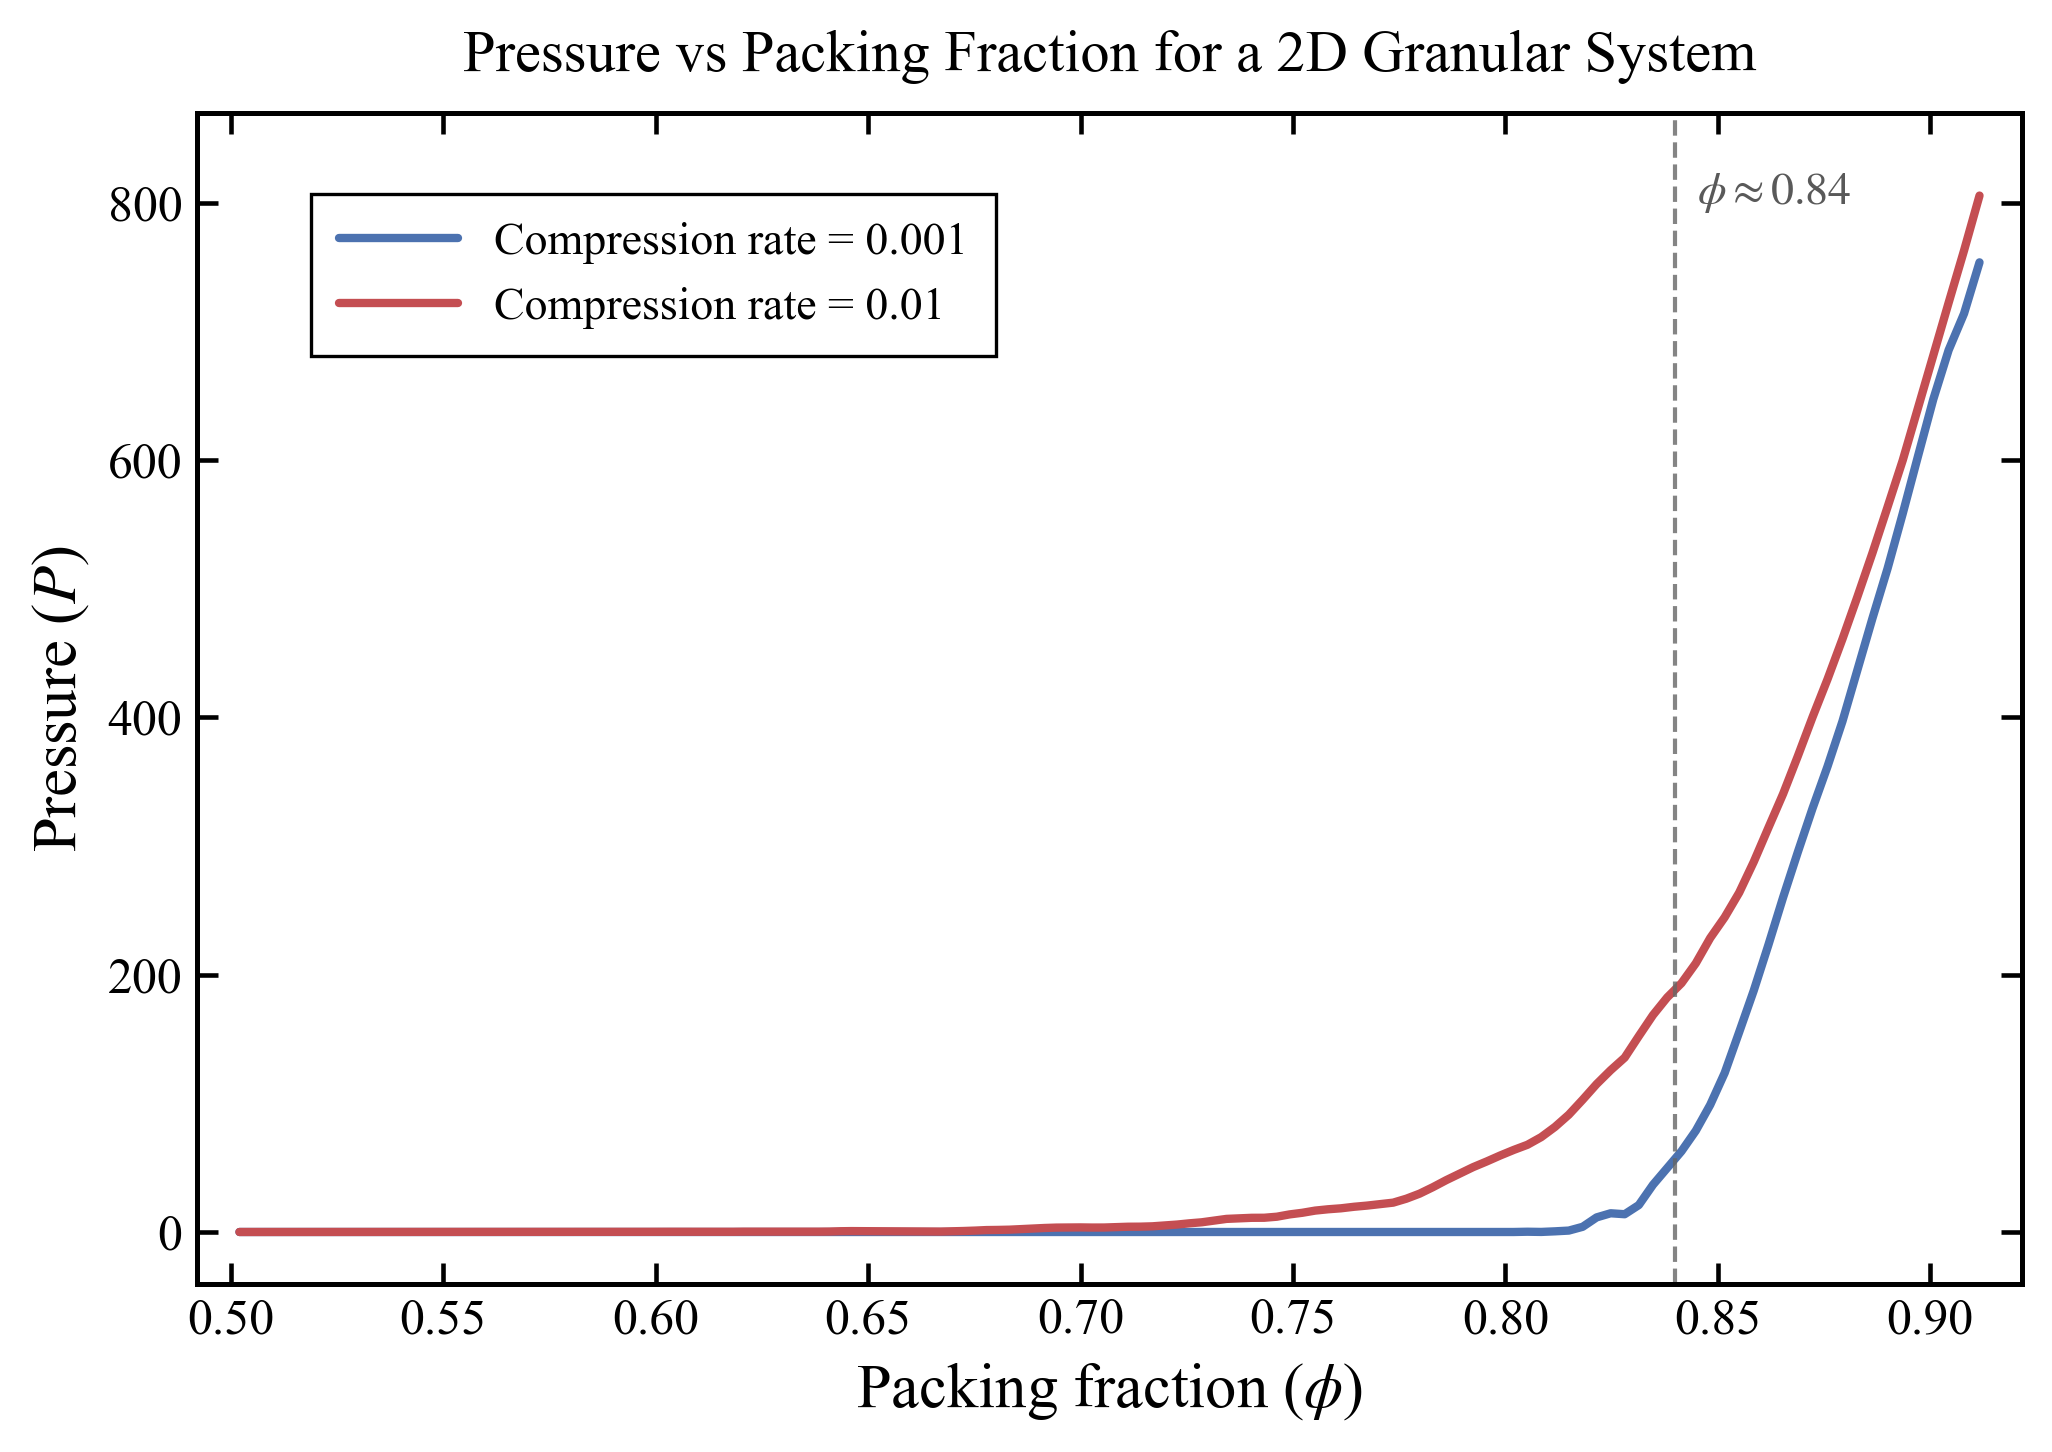

In [6]:
# ========= Nature-like style =========
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 12,
    "axes.labelsize": 15,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "axes.linewidth": 1.2,
})

# ========= muted colors =========
color_slow = "#4C72B0"   # muted blue
color_fast = "#C44E52"   # muted red

# ========= figure =========
fig, ax = plt.subplots(figsize=(7.0, 5.0), dpi=300)

ax.plot(
    phi_slow, press_slow,
    lw=2.0, color=color_slow,
    label=r"Compression rate = 0.001",
    solid_capstyle="round"
)

ax.plot(
    phi_fast, press_fast,
    lw=2.0, color=color_fast,
    label=r"Compression rate = 0.01",
    solid_capstyle="round"
)

# ========= optional reference line =========
phi_j = 0.84
ax.axvline(phi_j, color="0.4", lw=1.0, ls="--", alpha=0.8)
ax.text(
    phi_j + 0.005, 0.95, r"$\phi \approx 0.84$",
    transform=ax.get_xaxis_transform(),
    ha="left", va="top", fontsize=11, color="0.35"
)

# ========= axes =========
xmin = min(np.min(phi_slow), np.min(phi_fast))
xmax = max(np.max(phi_slow), np.max(phi_fast))
ymin = min(np.min(press_slow), np.min(press_fast))
ymax = max(np.max(press_slow), np.max(press_fast))

ax.set_xlim(max(0.0, xmin - 0.01), min(1.0, xmax + 0.01))
ax.set_ylim(ymin - 0.05 * (ymax - ymin), ymax + 0.08 * (ymax - ymin))

ax.set_xlabel(r"Packing fraction ($\phi$)")
ax.set_ylabel(r"Pressure ($P$)")

# ========= ticks =========
ax.tick_params(axis="both", which="major", direction="in",
               top=True, right=True, length=5, width=1.1)
ax.tick_params(axis="both", which="minor", direction="in",
               top=True, right=True, length=3, width=0.9)

# ========= legend with paper-style frame =========
leg = ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.05, 0.95),  # 👈 往里挪
    frameon=True,         # 打开边框
    fancybox=False,       # 直角框，更像论文
    framealpha=1.0,       # 不透明
    edgecolor="black",    # 黑色边框
    handlelength=2.6,
    borderpad=0.6
)
leg.get_frame().set_linewidth(0.8)   # 边框细一点，更像论文
leg.get_frame().set_facecolor("white")

# ========= spines =========
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color("black")

ax.set_title("Pressure vs Packing Fraction for a 2D Granular System", pad=10)

plt.tight_layout()
plt.savefig("pressure_phi_curves.png", dpi=600, bbox_inches="tight")
plt.show()